<a href="https://colab.research.google.com/github/felipe-lim4/study-ml-classification/blob/main/classificacao_validacao_metricas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color='dark'>**Classificação: Validação de modelos e métricas de avaliação**</h1>

### Projeto

Uma empresa de empréstimo de automóveis está passando por uma situação complicada, com alta demanda para uma frota reduzida de veículos e alto número de inadimplentes, trazendo um prejuízo grande para a empresa.

Nós fomos contratados para buscar melhorias na identificação de inadimplentes. A análise dos clientes atualmente é feita de forma manual, cliente por cliente, tomando muito tempo e ainda assim a detecção de inadimplentes é muito imprecisa.

Nossa tarefa é utilizar os dados fornecidos pela empresa para **classificar** os clientes em adimplentes e inadimplentes.

## <font color='dark'>Classificando dados</h1>

### Criando um modelo inicial

In [49]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/fontes/emp_automovel.csv')
data

# variaveis categoricas: telefone_trab, avaliação_cidade
# variaveis numericas: receita_cliente, anuidade_emprestimo, anos_casa_propria, score_1, score_2, score_3, score_social, troca_telefone

,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,12600.000000,3569.400000,12.157324,1,2.0,0.057153,0.527227,0.513171,0.117428,2545.000000,0
1,9000.000000,2722.188351,7.000000,0,2.0,0.657661,0.285898,0.614414,0.222700,495.000000,0
2,15750.000000,4477.500000,12.000000,0,2.0,0.501213,0.695423,0.513171,0.117428,1212.000000,0
3,9000.000000,1309.050000,12.157324,0,3.0,0.501213,0.155973,0.513171,0.117428,515.000000,0
4,7650.000000,1125.000000,12.157324,0,2.0,0.294328,0.152076,0.513171,0.117428,162.000000,0
...,...,...,...,...,...,...,...,...,...,...,...
54020,16855.246324,675.000000,12.157324,1,2.0,0.501213,0.180635,0.513171,0.082500,0.000000,1
54021,11250.000000,675.000000,14.000000,0,3.0,0.409620,0.606002,0.513171,0.117428,466.000000,1
54022,13500.000000,900.000000,64.000000,0,2.0,0.162632,0.525412,0.513171,0.117428,962.106056,1
54023,11250.000000,2371.500000,12.157324,0,3.0,0.501213,0.664027,0.513171,0.117428,482.000000,1


In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54025 entries, 0 to 54024
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   receita_cliente      54025 non-null  float64
 1   anuidade_emprestimo  54025 non-null  float64
 2   anos_casa_propria    54025 non-null  float64
 3   telefone_trab        54025 non-null  int64  
 4   avaliacao_cidade     54025 non-null  float64
 5   score_1              54025 non-null  float64
 6   score_2              54025 non-null  float64
 7   score_3              54025 non-null  float64
 8   score_social         54025 non-null  float64
 9   troca_telefone       54025 non-null  float64
 10  inadimplente         54025 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 4.5 MB


In [52]:

print((data['inadimplente'] == 0).sum())
print((data['inadimplente'] == 1).sum())

49309
4716


### Separando variaveis alvo e explicativas

In [53]:
x = data.drop('inadimplente', axis=1) # Retira a coluna de inadimplente
y = data['inadimplente']

In [54]:
from sklearn.tree import DecisionTreeClassifier

In [55]:
tree_model = DecisionTreeClassifier()
# IMPORTANTE: Caso as variaveis não fossem numericas, seria necessario fazer a conversão das variaveis categoricas (OneHotEncoder)
tree_model.fit(x,y)


DecisionTreeClassifier()

### Possivel overfitt

O score dos dados de treinamento com profundidade maxima da arvore foi == 1, indicando que ele acerta 100% dos casos. No entando, isso provavelmente indica que o modelo está simplesmente decorando os resultados, o melhor caminho seria verificar se isso é veridico testando com dados de teste, que não foram utilizados no treinamento.

In [56]:
print(f'acurácia do modelo (profundidade máxima): {tree_model.score(x,y)}')

acurácia do modelo (profundidade máxima): 1.0


### Separação de dados - Treino, Validação e Teste

In [57]:
from sklearn.model_selection import train_test_split

In [58]:
# Treino e validação
# Stratify mantém as proporções em treino e validação
# Text size é a proporção para cada 1, neste caso é 15% para validação
x, x_teste, y, y_teste = train_test_split(x, y, test_size=0.15, stratify = y, random_state=5)
x_treino, x_val, y_treino, y_val = train_test_split(x, y, stratify = y, random_state=5)


In [59]:
# Sem parâmetros com profundidade máxima
model_tree = DecisionTreeClassifier()
model_tree.fit(x_treino, y_treino)

DecisionTreeClassifier()

In [60]:
model_tree = DecisionTreeClassifier(max_depth=4)
model_tree.fit(x_treino, y_treino)

DecisionTreeClassifier(max_depth=4)

In [61]:
# Verificando acuracia
print(f'acurácia do modelo (profundidade máxima): {model_tree.score(x_treino,y_treino)}')
print(f'acurácia do modelo (profundidade máxima): {model_tree.score(x_val,y_val)}')
print(f'acurácia do modelo (profundidade máxima): {model_tree.score(x_teste,y_teste)}')

acurácia do modelo (profundidade máxima): 0.912862950058072
acurácia do modelo (profundidade máxima): 0.9127253723543245
acurácia do modelo (profundidade máxima): 0.9125123395853899


#### Análise de desempenho e Holdout
Há uma discrepancia entre as acurácias, o modelo de treino fica muito a frente, possivalmente pela decora dos resultados.

Fazendo uso o max_depth = 3, conseguimos fazer a poda da arvore, evitando que o modelo decore os dados, aumentando a acurácia nos dados de validação, fazendo o dado de score do treino e validação ficarem semelhantes entre si.

### Entendendo os resultados: Matriz de Confusão
Vamos avaliar quais dados o modelo trás como inadimplente ou não por meio da matriz de confusão, que mede positivos, negativos, falsos positivos e falsos negativos

In [62]:
from sklearn.metrics import confusion_matrix

In [63]:
y_previsto = model_tree.predict(x_val)
matriz_confusao = confusion_matrix(y_val, y_previsto)
print(f'matriz de confusão: \n{matriz_confusao}')

matriz de confusão: 
[[10479     0]
 [ 1002     0]]


In [64]:
from sklearn.metrics import ConfusionMatrixDisplay

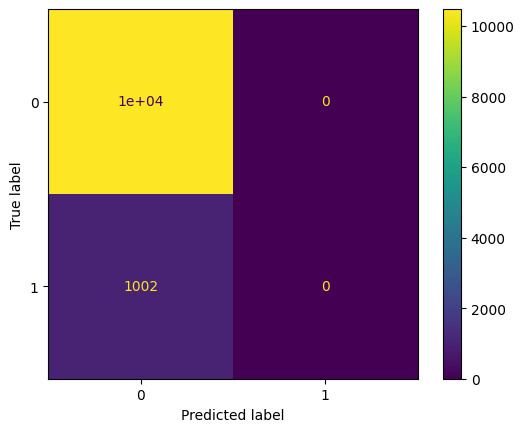

In [65]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao)
visualizacao.plot()

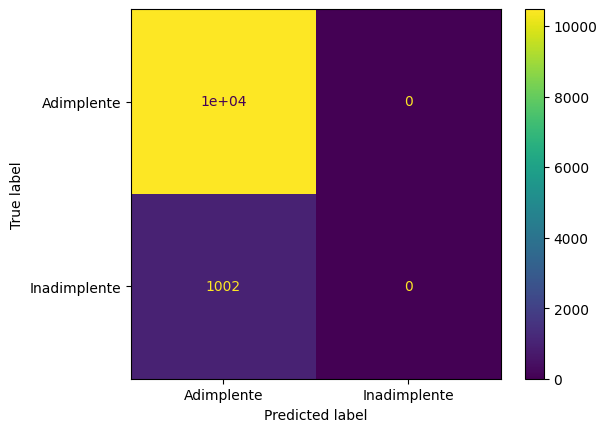

In [66]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=['Adimplente', "Inadimplente"])
visualizacao.plot()

Até ai já deu pra perceber que a acurácia por si só não serve como avaliação unica e exclusiva de que o modelo está bom. O problema raiz é a detecção automatica de cliente inadimplentes, mas ele erra por muito a quantidade de clientes inadimplentes.

In [71]:
vp = matriz_confusao[0,0]
fp = matriz_confusao[0,1]
vn = matriz_confusao[1,1]
fn = matriz_confusao[1,0]


print(f'Verdadeiros positivos: {vp}')
print(f'Falsos positivos: {fp}')
print(f'Verdadeiros negativos: {vn}')
print(f'Falsos negativos: {fn}')


# Vamos para uma ánalise mais detalhada, da para ver que ele erra muito ao tentar acertar verdadeiro negativo.
# Recall é a quantidade de positivos que o modelo acertou, comparada com o total de positivos reais (tudo o que existia de verdade).
# Precisão é a quantidade de positivos que o modelo acertou, comparada com o total de positivos preditos (tudo o que o modelo disse que era positivo).

print('\n\nRecall ou TPR (% vp comparada ao total de positivos reais):', vp/(vp+fn))
print('Precisão ou assertividade positiva (% de vp comparada a quantidade de acertos preditos pelo modelo)', vp/(vp+fp))
print(f'Acurácia do modelo (profundidade máxima): {model_tree.score(x_treino,y_treino)}')

Verdadeiros positivos: 10479
Falsos positivos: 0
Verdadeiros negativos: 0
Falsos negativos: 1002


Recall ou TPR (% vp comparada ao total de positivos reais): 0.9127253723543245
Precisão ou assertividade positiva (% de vp comparada a quantidade de acertos preditos pelo modelo) 1.0
Acurácia do modelo (profundidade máxima): 0.912862950058072


## Os dados podem mentir! - Dados desbalanceados e um overfit pesado
Como meus dados eram majoritariamente compostos por valores positivos, o modelo acabou por decorar os caminhos e chutar sempre positivos. O resultado bruto disso é que a acurácia ficou boa, a precisão ficou boa e o recall ficou excelente, mas em compensação, quando negativo ele não acertou nenhuma.